In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv('merged_dataset.csv')

In [4]:
df.head()

,Unnamed: 0,pr_id,ms_id,has_conflict,top_proj,top_proj_target,top_proj_source,occ_proj,occ_proj_target,occ_proj_source,...,num_integrators,num_leads_left,num_leads_right,total_files_changed,total_files_right,total_chunks_left,total_chunks_right,total_commits_left,total_commits_right,total_code_churn
0,1,2,1,0,0,0,0,1,1,0,...,1,1,0,5,0,5,0,1,0,163
1,2,2,5,0,1,1,1,0,0,0,...,1,1,1,34,15,877,15,3,2,9148
2,3,2,28,0,1,1,0,0,0,0,...,1,1,0,47,0,64,0,6,0,1317
3,4,2,32,0,1,1,0,0,0,0,...,1,1,0,3,0,7,0,2,0,141
4,5,2,34,0,1,1,0,0,0,0,...,1,1,0,1,0,31,0,1,0,31


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78740 entries, 0 to 78739
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed: 0           78740 non-null  int64
 1   pr_id                78740 non-null  int64
 2   ms_id                78740 non-null  int64
 3   has_conflict         78740 non-null  int64
 4   top_proj             78740 non-null  int64
 5   top_proj_target      78740 non-null  int64
 6   top_proj_source      78740 non-null  int64
 7   occ_proj             78740 non-null  int64
 8   occ_proj_target      78740 non-null  int64
 9   occ_proj_source      78740 non-null  int64
 10  top_ms               78740 non-null  int64
 11  top_ms_target        78740 non-null  int64
 12  top_ms_source        78740 non-null  int64
 13  occ_ms               78740 non-null  int64
 14  occ_ms_target        78740 non-null  int64
 15  occ_ms_source        78740 non-null  int64
 16  devs                 7

In [6]:
# number of conflicted MS
len(df[df["has_conflict"]==1])

3950

In [7]:
# number of non conflicted MS
len(df[df["has_conflict"]==0])

74790

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
# feature extraction
X = df.drop(columns=["Unnamed: 0","pr_id","ms_id", "has_conflict"]).values  # Remove non-feature columns
y = df["has_conflict"].values  # Target column

In [10]:
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [ ]:
def split_data(X, y, train_ratio=0.7, valid_ratio=0.15, test_ratio=0.15):
    assert train_ratio + valid_ratio + test_ratio == 1, "Ratios must sum to 1."
    
    dataset = TensorDataset(X, y)
    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    valid_size = int(valid_ratio * total_size)
    test_size = total_size - train_size - valid_size  # Ensures sum equals total
    
    train_data, valid_data, test_data = random_split(dataset, [train_size, valid_size, test_size])
    return train_data, valid_data, test_data

In [ ]:
train_dataset, valid_dataset, test_dataset =split_data(X_tensor,y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
# classifer
class MergeConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(MergeConflictPredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

In [16]:
input_size = X.shape[1]  # Number of features
model_1 = MergeConflictPredictor(input_size).to(device)
criterion_1 = nn.BCELoss()
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001)
print(model_1)

MergeConflictPredictor(
  (fc1): Linear(in_features=41, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [17]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)  # Move data to GPU if available
            optimizer.zero_grad()  # Reset gradients
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)  # Compute Focal Loss
            
            loss.backward()  # Compute gradients
            optimizer.step()  # Update model parameters
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [18]:
# Train the model
import time 
start_time = time.time()
train_model(model_1, train_loader, criterion_1, optimizer_1, epochs=80)
end_time = time.time()

elapsed_time = end_time - start_time

print(f"Total training time: {elapsed_time:.2f} seconds")

Epoch 1/80, Loss: 0.1031
Epoch 2/80, Loss: 0.0818
Epoch 3/80, Loss: 0.0794
Epoch 4/80, Loss: 0.0787
Epoch 5/80, Loss: 0.0775
Epoch 6/80, Loss: 0.0769
Epoch 7/80, Loss: 0.0762
Epoch 8/80, Loss: 0.0757
Epoch 9/80, Loss: 0.0758
Epoch 10/80, Loss: 0.0747
Epoch 11/80, Loss: 0.0744
Epoch 12/80, Loss: 0.0739
Epoch 13/80, Loss: 0.0742
Epoch 14/80, Loss: 0.0741
Epoch 15/80, Loss: 0.0727
Epoch 16/80, Loss: 0.0729
Epoch 17/80, Loss: 0.0717
Epoch 18/80, Loss: 0.0721
Epoch 19/80, Loss: 0.0713
Epoch 20/80, Loss: 0.0719
Epoch 21/80, Loss: 0.0710
Epoch 22/80, Loss: 0.0704
Epoch 23/80, Loss: 0.0705
Epoch 24/80, Loss: 0.0697
Epoch 25/80, Loss: 0.0693
Epoch 26/80, Loss: 0.0690
Epoch 27/80, Loss: 0.0701
Epoch 28/80, Loss: 0.0682
Epoch 29/80, Loss: 0.0679
Epoch 30/80, Loss: 0.0675
Epoch 31/80, Loss: 0.0676
Epoch 32/80, Loss: 0.0670
Epoch 33/80, Loss: 0.0665
Epoch 34/80, Loss: 0.0662
Epoch 35/80, Loss: 0.0661
Epoch 36/80, Loss: 0.0656
Epoch 37/80, Loss: 0.0656
Epoch 38/80, Loss: 0.0646
Epoch 39/80, Loss: 0.

In [49]:
# Function to evaluate the model
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            predictions = (outputs > 0.5).float()  # Convert probabilities to binary predictions
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Conflict", "Conflict"], yticklabels=["No Conflict", "Conflict"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Accuracy: 0.9627
Precision: 0.6605
Recall: 0.5402
F1 Score: 0.5943


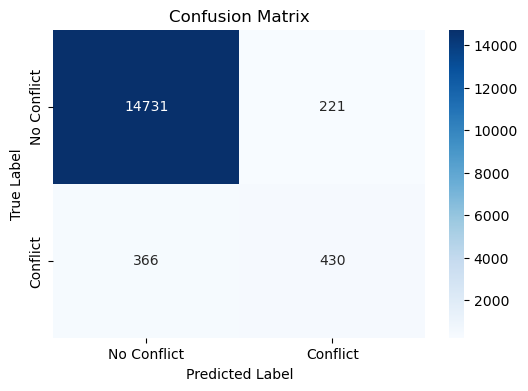

In [50]:
evaluate_model(model_1, test_loader)

In [20]:
# compare with dummy classifier 
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")  # Always predicts the majority class
dummy.fit(X_train.cpu().numpy(), y_train.cpu().numpy())
dummy_preds = dummy.predict(X_test.cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(y_test.cpu().numpy(), dummy_preds))

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     14952
         1.0       0.00      0.00      0.00       796

    accuracy                           0.95     15748
   macro avg       0.47      0.50      0.49     15748
weighted avg       0.90      0.95      0.92     15748



C:\Users\engpe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\engpe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\engpe\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Merge Conflict Prediction - Current Findings

## 1. Overview
This study aims to predict merge conflicts in software repositories by analyzing social and technical factors. A deep learning model was trained to classify merge scenarios as conflict (`1`) or no-conflict (`0`).

## 2. Baseline (Dummy Model)
A dummy classifier that always predicts `0` was used as a benchmark.

**Results:**
- **Accuracy:** 95% (misleading due to class imbalance)
- **Precision (Conflicts):** 0.00
- **Recall (Conflicts):** 0.00
- **Conclusion:** The dummy model fails to detect conflicts, proving that our deep learning model must do better.

## 3. Deep Learning Model Results
After applying SMOTE oversampling (`0.3` ratio), the deep learning model achieved:

- **Accuracy:** 92.74%
- **Precision:** 40.22%
- **Recall:** 89.95%
- **F1 Score:** 55.59%

## 4. Observations
- **High recall (89.95%)** means the model detects most actual conflicts.
- **Low precision (40.22%)** means too many false positives (wrong conflict predictions).
- **SMOTE helped recall but may have intro- so far **our model** could be usefull if we care about detacting conflict Merges

## 5. Next step
To improve precision without harming recall:
1. **Apply Active Learning** to focus training on uncertain/confusing merge scenarios.
2. **Test different deep learning architectures** (e.g., deeper FCNN, Transformer models).
3. **Increase decision threshold (e.g., 0.4 or 0.5) to reduce false positives.**
4. **Try Focal Loss instead of BCE Loss for better balance.**
5. **Fine-tune SMOTE ratio (e.g., 0.2 instead of 0.3) to avoid over-sampling conflicts.**
6. **Test model stability across multiple runs to confirm consistency.**de to improve model performance.

